In [1]:

import pandas as pd
import numpy as np

import re
import string

import nltk

from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.stem import LancasterStemmer
from nltk.stem import WordNetLemmatizer

from nltk.tokenize import word_tokenize
from nltk.tokenize import sent_tokenize

from nltk.util import ngrams

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction.text import CountVectorizer


from sklearn.linear_model import LogisticRegression

from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score

from sklearn.metrics import confusion_matrix 

from sklearn.metrics import classification_report

from sklearn.metrics import precision_score

from sklearn.metrics import recall_score

from sklearn.metrics import f1_score

import pickle
import joblib

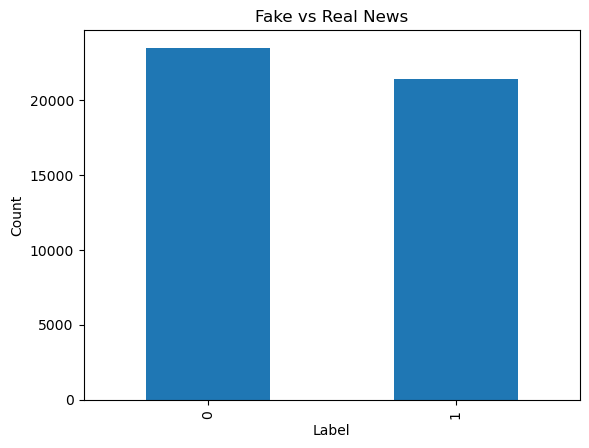

In [2]:
fake_df = pd.read_csv("Fake.csv")
true_df = pd.read_csv("True.csv")

fake_df["label"] = 0
true_df["label"] = 1

df = pd.concat([fake_df, true_df], axis=0)
df["label"].value_counts().plot(kind="bar")
plt.title("Fake vs Real News")
plt.xlabel("Label")
plt.ylabel("Count")
plt.show()

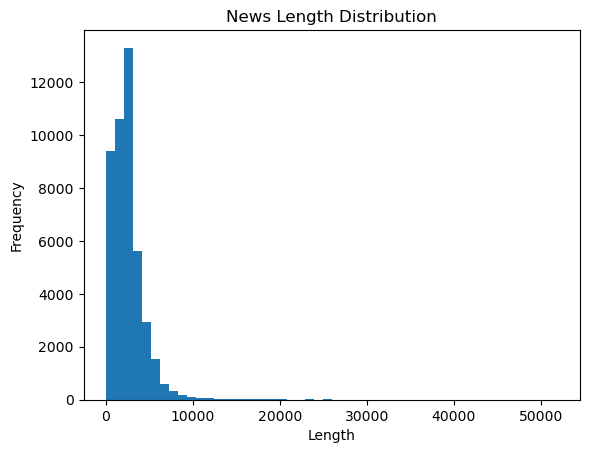

In [3]:
df = df.sample(frac=1)
df.reset_index(inplace=True, drop=True)

df = df[["title", "text", "label"]]
df["content"] = df["title"] + " " + df["text"]


df["length"] = df["content"].apply(len)
plt.hist(df["length"], bins=50)
plt.title("News Length Distribution")
plt.xlabel("Length")
plt.ylabel("Frequency")
plt.show()

In [4]:
nltk.download('stopwords')
# # Download English stopwords from NLTK library
# Stopwords are common words like:
# the, is, are, was, in, on, and

# These words do not help much in prediction
# Removing them improves NLP model performance

stemmer = PorterStemmer()
stop_words = stopwords.words("english")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\praj2\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [10]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"\d+", "", text)
    text = text.translate(
        str.maketrans("", "", string.punctuation)
    )
    words = text.split()
    words = [
        stemmer.stem(word)
        for word in words
        if word not in stop_words
    ]
    return " ".join(words)

df["content"] = df["content"].apply(clean_text)

In [11]:
X = df["content"]
y = df["label"]

vectorizer = TfidfVectorizer(max_features=5000)
X = vectorizer.fit_transform(X)

x_train, x_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [13]:
logistic_model = LogisticRegression()
logistic_model.fit(x_train, y_train)
logistic_prediction = logistic_model.predict(x_test)

In [14]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

logistic_accuracy = accuracy_score(
    y_test,
    logistic_prediction
)
logistic_precision = precision_score(
    y_test,
    logistic_prediction
)
logistic_recall = recall_score(
    y_test,
    logistic_prediction
)
logistic_f1 = f1_score(
    y_test,
    logistic_prediction
)

print("Accuracy :", logistic_accuracy)
print("Precision :", logistic_precision)
print("Recall :", logistic_recall)
print("F1 Score :", logistic_f1)

Accuracy : 0.9899777282850779
Precision : 0.9877908316056209
Recall : 0.9914450867052023
F1 Score : 0.9896145857373644


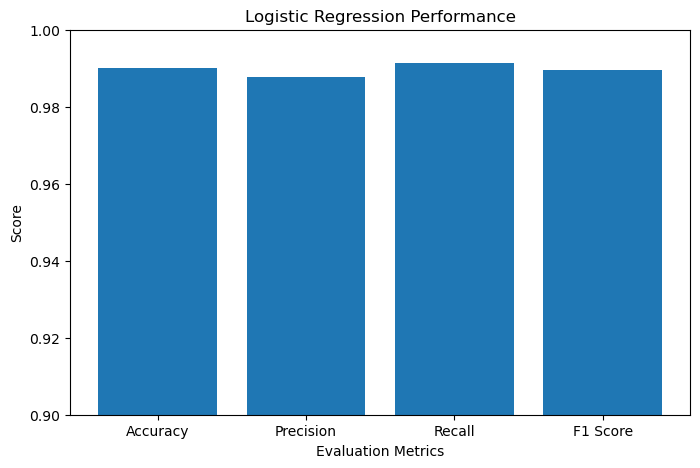

In [15]:
logistic_metric_names = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score"
]

logistic_metric_values = [
    logistic_accuracy,
    logistic_precision,
    logistic_recall,
    logistic_f1
]

plt.figure(figsize=(8,5))
plt.bar(
    logistic_metric_names,
    logistic_metric_values
)
plt.ylim(0.9, 1.0)
plt.xlabel("Evaluation Metrics")
plt.ylabel("Score")
plt.title("Logistic Regression Performance")
plt.show()

Cross Validation Scores :
[0.98697105 0.99053452 0.98919822 0.9896425  0.98908564]
Average Accuracy :
0.989086385927471


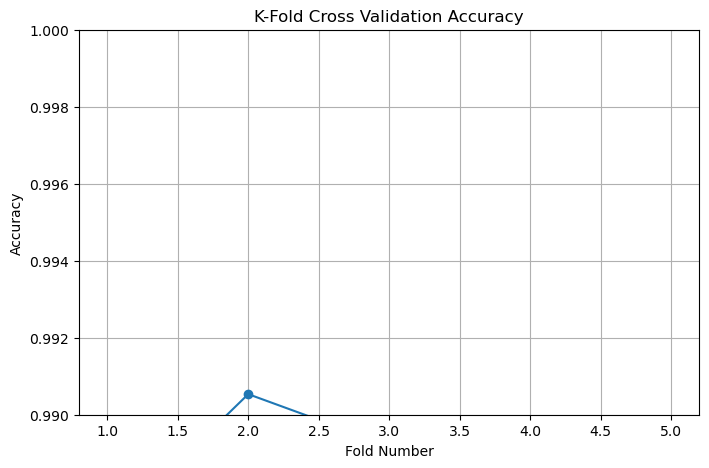

In [16]:
cross_scores = cross_val_score(
    logistic_model,
    X,
    y,
    cv=5,
    scoring="accuracy"
)

print("Cross Validation Scores :")
print(cross_scores)

print("Average Accuracy :")
print(cross_scores.mean())

fold_numbers = [1, 2, 3, 4, 5]

plt.figure(figsize=(8,5))
plt.plot(
    fold_numbers,
    cross_scores,
    marker="o"
)
plt.xlabel("Fold Number")
plt.ylabel("Accuracy")
plt.title("K-Fold Cross Validation Accuracy")
plt.ylim(0.99, 1.0)
plt.grid(True)
plt.show()

Real News
[[0.41078618 0.58921382]]
Fake Probability : 41.07861812070944
Real Probability : 58.92138187929056


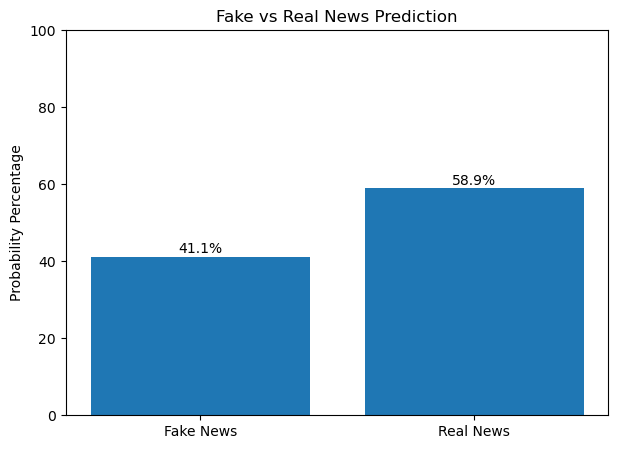

In [20]:
sample_news = """

But beyond the pomp as he welcomed President Trump, President Xi used less effusive tones, saying the two sides “should be partners and not rivals” and highlighting the issue of self-ruled democratic Taiwan — which Beijing claims as its territory — straight off the ba"""

clean_news = clean_text(sample_news)
news_vector = vectorizer.transform([clean_news])
prediction = logistic_model.predict(news_vector)

if prediction[0] == 0:
    print("Fake News")
else:
    print("Real News")

probability = logistic_model.predict_proba(news_vector)
print(probability)

fake_probability = probability[0][0] * 100
real_probability = probability[0][1] * 100
print("Fake Probability :", fake_probability)
print("Real Probability :", real_probability)


labels = [
    "Fake News",
    "Real News"
]

values = [
    fake_probability,
    real_probability
]


plt.figure(figsize=(7,5))

bars = plt.bar(
    labels,
    values
)

plt.ylabel("Probability Percentage")

plt.title("Fake vs Real News Prediction")

plt.ylim(0, 100)

for bar in bars:

    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 1,
        f"{height:.1f}%",
        ha="center"
    )

plt.show()